# K-means clustering. Dataset: mnist

### Libraries and constants

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from utils import (
    get_null_info,
    target_info,
)
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import FunctionTransformer

In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42

### Data import

In [3]:
df_raw = pd.read_csv(
    Path('data') / 'mnist.csv',
    header=None,                                    # tells the first row is regular data; prevents the first entry from being lost or turned into a column title
    names=[f'feat{i}' for i in range(785)],         # explicit feature names
)

df_raw

,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,feat784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


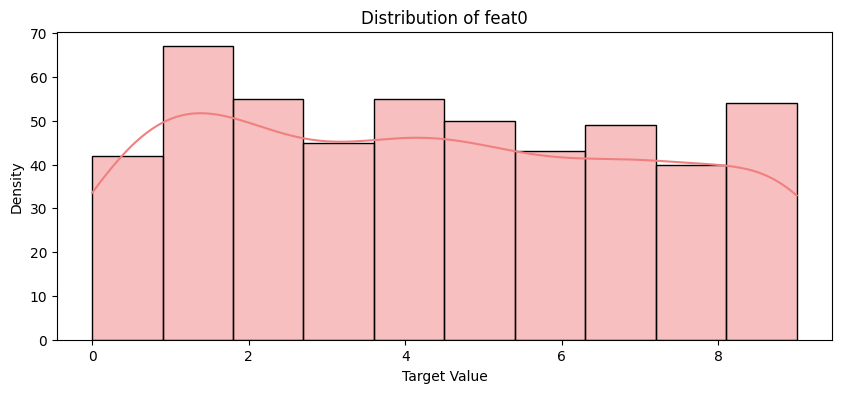

,counts,%
feat0,,
0,42,0.08
1,67,0.13
2,55,0.11
3,45,0.09
4,55,0.11
5,50,0.10
6,43,0.09
7,49,0.10
8,40,0.08


In [4]:
target_inf = target_info(df_raw, 'feat0').sort_index()
target_inf

This looks like the same story as in `main_2d.ipynb`, the first column is a label.

In [5]:
df_raw = df_raw.rename(columns={'feat0': 'label'})
display(df_raw)

print()


X = df_raw.drop(columns=['label'])
display(X)

,label,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,feat784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,feat784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Data overview and typing

In [6]:
duplicates_df = X[X.duplicated()]
duplicates_df

,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,feat784


In [7]:
X.describe()

,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,feat784
count,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,...,500.000000,500.000000,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.506000,0.256000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.314504,5.724334,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,128.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Looks like the majority of pixels are just empty, they are background. They carry no essential information. A column with zero variance is mathematically incapable of contributing to any distance calculation. We might as well just leave them be to be handled by PCA, but if anything, it will only slow it down and complicate the matter.

In [8]:
constant_features = X.columns[X.var() == 0.0].tolist()
print(f"Constant features ({len(constant_features)}: {constant_features}")

Constant features (209: ['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13', 'feat14', 'feat15', 'feat16', 'feat17', 'feat18', 'feat19', 'feat20', 'feat21', 'feat22', 'feat23', 'feat24', 'feat25', 'feat26', 'feat27', 'feat28', 'feat29', 'feat30', 'feat31', 'feat32', 'feat33', 'feat34', 'feat35', 'feat36', 'feat37', 'feat41', 'feat42', 'feat43', 'feat44', 'feat45', 'feat46', 'feat47', 'feat48', 'feat49', 'feat50', 'feat51', 'feat52', 'feat53', 'feat54', 'feat55', 'feat56', 'feat57', 'feat58', 'feat59', 'feat60', 'feat61', 'feat62', 'feat63', 'feat64', 'feat65', 'feat79', 'feat80', 'feat81', 'feat82', 'feat83', 'feat84', 'feat85', 'feat86', 'feat87', 'feat88', 'feat89', 'feat90', 'feat91', 'feat109', 'feat110', 'feat111', 'feat112', 'feat113', 'feat114', 'feat115', 'feat116', 'feat139', 'feat140', 'feat141', 'feat142', 'feat143', 'feat144', 'feat168', 'feat169', 'feat170', 'feat171', 'feat196', 'feat197', 'feat198', 'fe

In [9]:
X_no_bg = X.drop(columns=constant_features)

In [10]:
X_no_bg.dtypes

feat38     int64
feat39     int64
feat40     int64
feat66     int64
feat67     int64
           ...  
feat772    int64
feat773    int64
feat774    int64
feat775    int64
feat776    int64
Length: 575, dtype: object

### Data visualization

I see no point in plotting this many features, even without the constant. 

In order to properly analyze feature space, we ought to deal with null values and outliers first. PCA can't handle nulls and is sensitive to outliers.

### Missing values overview

In [11]:
X_no_bg_nulls = get_null_info(X_no_bg)
X_no_bg_nulls

No missing values are found in the data_frame


""


### Outlier detection overview

Since pixel intensities are bounded to [0,255] by construction, there are no "extreme value" outliers the way there are in price or sensor data. The only kind of "outlier" here is a whole image that's unusually drawn (a bizarre 7, a smudge), and that's a multivariate, whole-row phenomenon. If considering, should be done after PCA.

### Scaling

`StandardScaler` can backfire on images. Pixels that are nonzero in only a handful of images get divided by a tiny std, exploding their values. The industry standard is to normalize pixels between [0,1] by dividing by 255.0.

### Dimensionality reduction

Scaling is mandatory - PCA maximizes variance, and an unscaled large-unit feature would dominate purely because of its units, not its importance.

In [ ]:
# ---------- STEP 1: Scale and Fit PCA ----------
# Scaling is mandatory - PCA maximizes variance, and an unscaled large-unit feature would dominate purely because of its units, not its importance.
pca_pipeline = Pipeline([
    ('scaler', FunctionTransformer(lambda df: df.copy() / 255.0)),  # or regular StandardScaler() if not pixel data
    ('pca', PCA(
        n_components=None,              # None = keep all, decide k after
        random_state=RANDOM_SEED,
        )),
])

pca_pipeline.fit(X_no_bg)

# ---------- STEP 2: Explained variance: how many components to keep ----------
pca_step = pca_pipeline.named_steps['pca']

# a list of percentages that tells how much information (variance) that specific Principal Component captures from the original data
# For example, if the first value is 0.40, it means Principal Component 1 holds 40% of the total data's variance
explained = pca_step.explained_variance_ratio_

# cumulative sums represents how much total information will be kept if we cut off
# for example, pc1 = pc1, pc2 = pc1+pc2, pc3=pc1+pc2+pc3 etc. Decided to drop to 2D the total remaining data is: (pc1+pc2)%
cumulative = np.cumsum(explained)

# ---------- STEP 3: Establish an arbitrary conservative threshold of 0.95 of information to preserve ----------
# return the very first index of max element (True that is), adding 1 to account for 0 index
# jt returns the number of components to keep to retain 95% of information
k_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components to retain 95% variance: {k_95}")
print(f"Sanity check. Variance explained by first {k_95}: {cumulative[k_95-1]:.4f}")

Components to retain 95% variance: 114
Sanity check. Variance explained by first 114: 0.9500


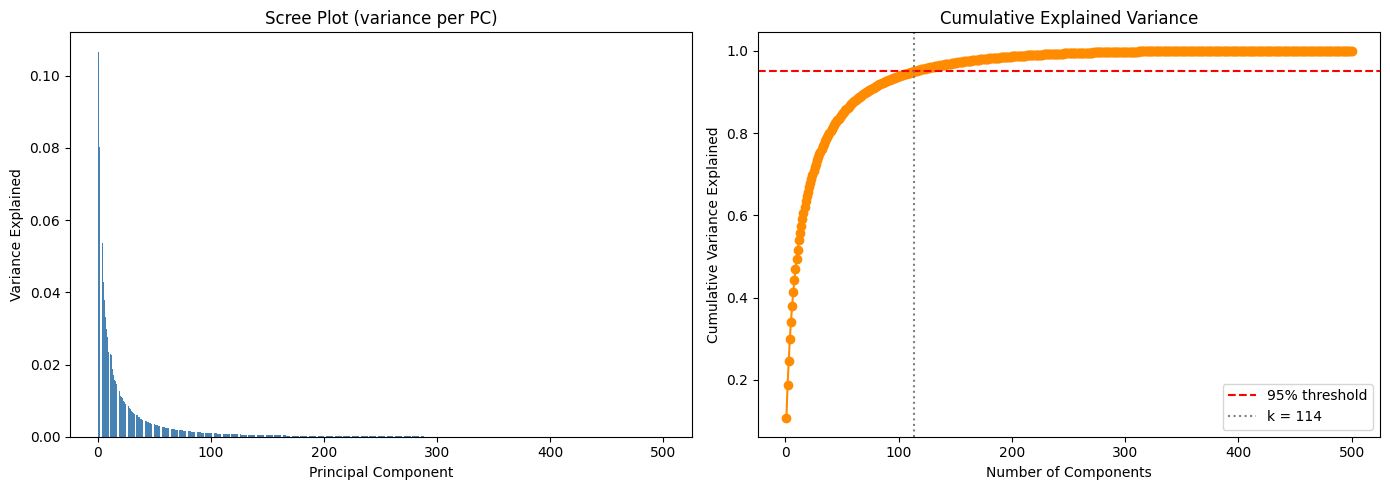

In [17]:
# ---------- STEP 4: Scree plot + cumulative curve to assess the threshold ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# max features to plot (in case it's too cluttered with bars)
max_display = len(pca_step.components_)
x_range = range(1, max_display + 1)

# Plot 1: Scree plot to see the variance reduction
ax1.bar(x_range, explained[:max_display], color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained')
ax1.set_title('Scree Plot (variance per PC)')

# Plot 2: Different perspective with the threshold plotted
ax2.plot(range(1, len(cumulative) + 1), cumulative, 'o-', color='darkorange')
ax2.axhline(0.95, color='red', linestyle='--', label='95% threshold')
ax2.axvline(k_95, color='gray', linestyle=':', label=f'k = {k_95}')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.show()

The scree plot confirms the explained variance drops off roughly after a value for `PC100`. The selected base threshold of `0.95` (corresponding to `114` components) is correct and shall not be changed.

In [23]:
# ---------- STEP 5: Refit with chosen k and apply the feature reduction ----------
final_pca = Pipeline([
    ('scaler', FunctionTransformer(lambda df: df.copy() / 255.0)),  # or regular StandardScaler() if not pixel data
    ('pca', PCA(n_components=k_95, random_state=RANDOM_SEED)),
])
X_reduced = final_pca.fit_transform(X_no_bg)   # shape: (n_samples, k_95)
print(f"Reduced shape: {X_no_bg.shape} -> {X_reduced.shape}")

# ---------- STEP 6: Inspect loadings ----------
# How much each original feature contributes to each PC
# Rows = PCs, columns = original features. Large |value| = strong contribution.
loadings = pd.DataFrame(
    final_pca.named_steps['pca'].components_,
    columns=X_no_bg.columns,
    index=[f'PC{i+1}' for i in range(k_95)],
)

print("\nTop feature loadings for PC1:")
display(loadings.loc['PC1'].abs().sort_values(ascending=False).head(5))

Reduced shape: (500, 575) -> (500, 114)

Top feature loadings for PC1:


feat579    0.104800
feat606    0.104498
feat551    0.103769
feat318    0.100457
feat552    0.099510
Name: PC1, dtype: float64

### Outlier detection

`IsolationForest` is best for high-dimensional, large, non-Gaussian multivariate data. We don't know how smudgy, blurred or well-written the images are. We are going to flag 1% of the easiest to isolate points, then plot them for assessment.

Train anomalies flagged: 5
[-0.5136425018377421, -0.4982686718880343, -0.49668442398155377, -0.4914478074042506, -0.49139460561637527]


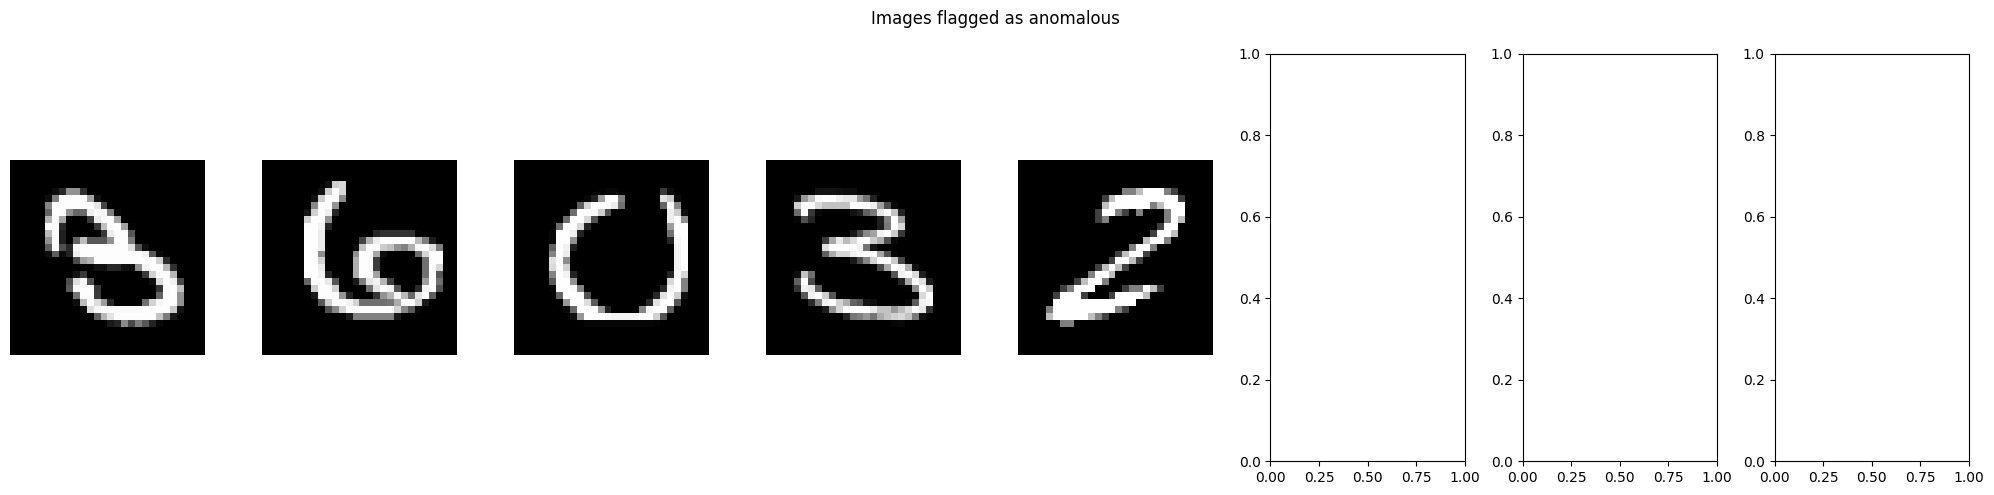

In [ ]:
# ---------- STEP 1: Fit ----------
# contamination = expected fraction of outliers.
# max_samples='auto' lets sklearn decide but is often too aggressive.
iso = IsolationForest(
    n_estimators=200,        # number of random trees
    contamination=0.01,      # expect ~1% anomalies (can also take 'auto')
    max_samples='auto',      # subsample size per tree
    random_state=RANDOM_SEED # fix for reproducibility (method is random)
)

iso.fit_predict(X_reduced)

# ---------- STEP 2: Predict (-1 = anomaly, 1 = normal) and print ----------
flags = iso.predict(X_reduced)
anomaly_mask = flags == -1
print(f"Train anomalies flagged: {anomaly_mask.sum()}")

# ---------- STEP 3: Get top 5 continuous anomaly scores for ranking ----------
# Lower score = more anomalous
anomaly_score = iso.score_samples(X_reduced)
print(sorted(anomaly_score)[:5])

# ---------- STEP 4: See the flagged images — this is the actual decision step. ----------
outlier_idx = np.where(flags == -1)[0]

fig, axes = plt.subplots(1, 8, figsize=(20, 5))
for ax, idx in zip(axes.ravel(), outlier_idx[:16], strict=False):
    ax.imshow(df_raw.drop(columns=['label']).iloc[idx].to_numpy().reshape(28, -1), cmap='gray')
    ax.axis('off')
fig.suptitle("Images flagged as anomalous")
plt.tight_layout()
plt.show()

The images look fine and decipherable, no need to remove anything.

### K-means clustering

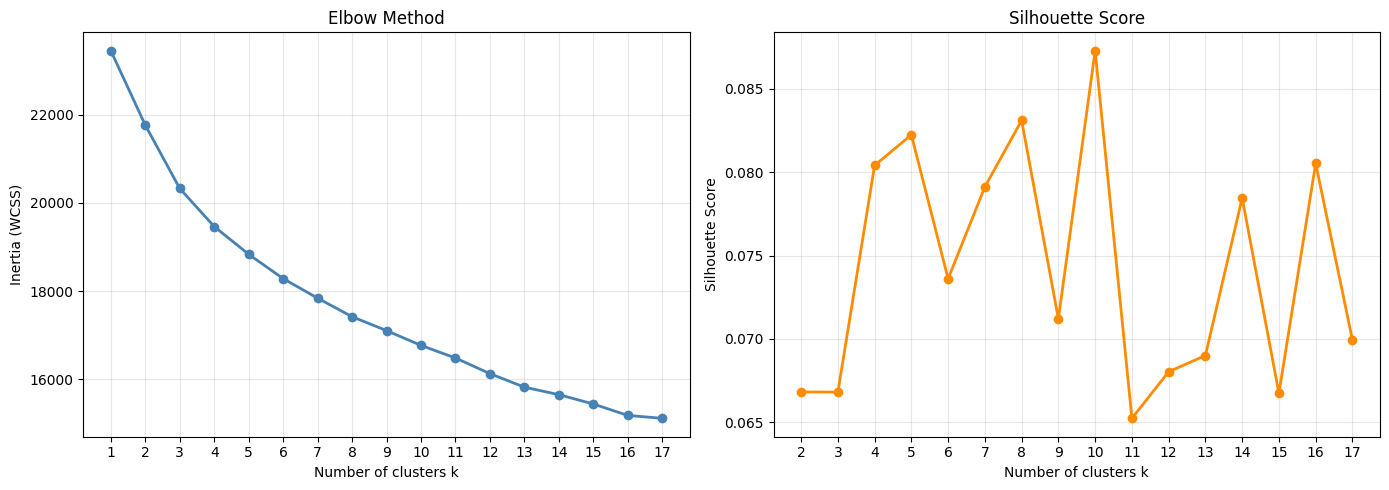

In [31]:
# ---------- STEP 1: Fit the model ----------
k_range = range(1, 18)                  # presumable number of clusters to try out
inertias = []                           # inertias to accumulate
silhouette_scores = []                  # silhouette scores to accumulate

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,                  # run 10 times for current k, return the lowest-inertia result
        max_iter=300,               # fallback convergence cap (to prevent infinite loops on non-converging initializations)
        random_state=RANDOM_SEED,
    )
    kmeans.fit(X_reduced)
    inertias.append(kmeans.inertia_)

    # silhouette undefined for k=1 (only one cluster, no comparison possible)
    if k >= 2:
        silhouette_scores.append(silhouette_score(X_reduced, kmeans.labels_))
    else:
        silhouette_scores.append(None)

# ---------- STEP 2: Plotting ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PLOT 1: Elbow plot
ax1.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.3)

# PLOT 2: Silhouette plot
valid_k = [k for k in k_range if k >= 2]                                    # exclude k=1 from Silhouette scores
valid_scores = [s for s in silhouette_scores if s is not None]              # exclude k=1 from Silhouette scores
ax2.plot(valid_k, valid_scores, 'o-', color='darkorange', linewidth=2)
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.set_xticks(valid_k)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This is a wonderful example of when the Elbow method is wrong. Based on it, we are supposed to have 3 classes, which is definitely wrong. The signal of Silhouette Score is strong and firmly suggests 10 clusters. The highest score is < 0.09 and the scores overall are close to 0 - this is evidence of the fact that points sit near a cluster boundary - the ambiguous assignment. Surely, the optimal $k$ is the one where the elbow and the silhouette peak agree. When they disagree, it is standard to prefer the silhouette - it is a direct, interpretable measure of cluster quality rather than a visual judgment call.

In [38]:
# ---------- Fit final model at chosen k ----------
OPTIMAL_K = 10

final_pipeline = Pipeline([
    ('drop_constants', FunctionTransformer(lambda df: df.copy().drop(columns=X.columns[X.var() == 0.0].tolist()))),
    ('scaler', FunctionTransformer(lambda df: df.copy() / 255)),
    ('pca', PCA(n_components=k_95, random_state=RANDOM_SEED)),
    ('kmeans', KMeans(
        n_clusters=OPTIMAL_K,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=RANDOM_SEED,
    )),
])

final_pipeline.fit(X)
labels = final_pipeline.named_steps['kmeans'].labels_

print(f"Chosen k: {OPTIMAL_K}")
print(f"Final inertia: {final_pipeline.named_steps['kmeans'].inertia_:.4f}")
print(f"Silhouette score: {silhouette_score(final_pipeline.named_steps['scaler'].transform(X_reduced), labels):.4f}")
print(f"Cluster sizes: {dict(zip(*np.unique(labels, return_counts=True), strict=True))}")

Chosen k: 10
Final inertia: 16772.1406
Silhouette score: 0.0873
Cluster sizes: {0: 29, 1: 55, 2: 33, 3: 94, 4: 49, 5: 74, 6: 36, 7: 40, 8: 67, 9: 23}


### Conclusion

`K-means` has correctly recovered the cluster count (10) via Silhouette scores, and separates visually-distinct digits well, but conflates digits with similar pixel shapes — an expected limitation of Euclidean distance on raw pixel geometry,